# Telecom Customer Churn Prediction using Support Vector Machine (SVM)

## Objective
The objective of this notebook is to build and evaluate a Support Vector Machine (SVM) model for predicting customer churn in a telecom dataset.

## Background
Customer churn prediction is a binary classification problem where the goal is to identify whether a customer is likely to leave the telecom service. Since retaining existing customers is important for business growth, machine learning models can be used to predict churn in advance.

## My Contribution
In this part of the group assignment, the SVM algorithm is implemented and evaluated. The preprocessing from the group work is reused through the processed dataset, and additional SVM-specific preprocessing such as feature scaling is applied before training.

## Workflow
1. Load the processed dataset  
2. Perform basic checks  
3. Split features and target  
4. Apply scaling  
5. Train the SVM model  
6. Evaluate performance using suitable metrics

## Import Required Libraries
The following libraries are required for data handling, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the Processed Dataset

The dataset used in this project has already been preprocessed as part of the group work.  
This includes handling missing values, encoding categorical variables, and cleaning the data.

For this model, the processed dataset is directly used to ensure consistency across all models.

In [2]:
# Load dataset
data_path = '../Dataset/Processed_Telecom_Churn.csv'

df = pd.read_csv(data_path)

# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,1,0,1,0,1,29.85,29.85,True,...,False,False,False,False,False,False,False,True,False,0
1,1,0,0,0,34,1,0,56.95,1889.50,False,...,False,False,False,False,True,False,False,False,True,0
2,1,0,0,0,2,1,1,53.85,108.15,False,...,False,False,False,False,False,False,False,False,True,1
3,1,0,0,0,45,0,0,42.30,1840.75,True,...,False,False,False,False,True,False,False,False,False,0
4,0,0,0,0,2,1,1,70.70,151.65,False,...,False,False,False,False,False,False,False,True,False,1


## Feature and Target Separation

In this step, the dataset is divided into:
- **Features (X)** → input variables used for prediction  
- **Target (y)** → output variable (Churn)

The target variable **Churn** indicates whether a customer has left the service.

In [3]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Ensure all features are numeric (important for SVM)
X = X.astype(float)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Check class distribution
print("\nClass Distribution:")
print(y.value_counts())

Features shape: (7032, 30)
Target shape: (7032,)

Class Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


## Train-Test Split

The dataset is split into training and testing sets.

- Training set → used to train the model  
- Testing set → used to evaluate model performance  

Stratified sampling is used to maintain the same class distribution in both sets.

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (5625, 30)
Testing set shape: (1407, 30)

Training class distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing class distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


## Feature Scaling

Feature scaling is applied to standardize the range of independent variables.

This is especially important for Support Vector Machine (SVM) because:
- SVM is sensitive to feature magnitudes
- It uses distance-based calculations to find the optimal hyperplane

StandardScaler is used to transform the data so that:
- Mean = 0
- Standard deviation = 1

In [5]:
# Feature scaling
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## Handling Class Imbalance using SMOTE

The dataset is imbalanced, with significantly more non-churn customers than churn customers.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) is applied:
- It generates synthetic samples for the minority class (churn)
- This helps the model learn better patterns for churn prediction

SMOTE is applied **only on the training data** to avoid data leakage.

In [6]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


## Training the SVM Model

In this step, a Support Vector Machine (SVM) model is trained using the balanced training dataset.

- Kernel used: Radial Basis Function (RBF)
- SVM is effective for classification problems and can model non-linear relationships

The model is trained using the resampled (balanced) dataset.

In [7]:
# Train SVM model
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_resampled, y_train_resampled)

print("SVM model trained successfully!")

SVM model trained successfully!


## Model Predictions

After training the SVM model, predictions are made on the test dataset to evaluate its performance on unseen data.

In [8]:
# Make predictions
y_pred = svm_model.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


## Model Evaluation

The performance of the SVM model is evaluated using:

- Accuracy
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)

These metrics provide a better understanding of model performance, especially for imbalanced datasets.

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.7526652452025586

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407


Confusion Matrix:
 [[790 243]
 [105 269]]


## Confusion Matrix Visualization

A confusion matrix is plotted to visualize the performance of the model.

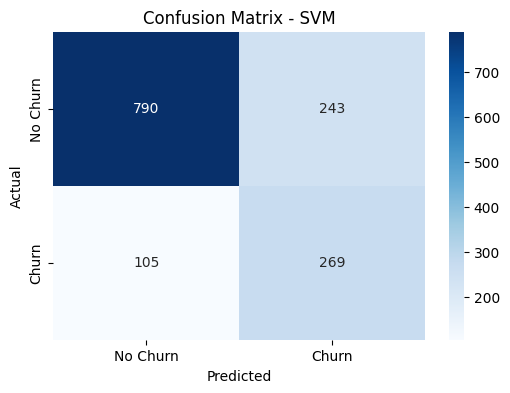

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

## Hyperparameter Tuning using GridSearchCV

To improve the performance of the SVM model, hyperparameter tuning is performed using GridSearchCV.

The following parameters are tuned:
- C → Controls regularization strength
- gamma → Controls influence of individual data points
- kernel → Type of decision boundary

GridSearchCV uses cross-validation to find the best combination of parameters.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

# GridSearch
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Best model
best_svm = grid_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score: 0.8614454429700782


In [12]:
y_pred_best = best_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Accuracy: 0.7391613361762616

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1033
           1       0.51      0.58      0.54       374

    accuracy                           0.74      1407
   macro avg       0.67      0.69      0.68      1407
weighted avg       0.75      0.74      0.74      1407



## ROC Curve

The ROC curve is used to evaluate the performance of the model by plotting the True Positive Rate against the False Positive Rate.

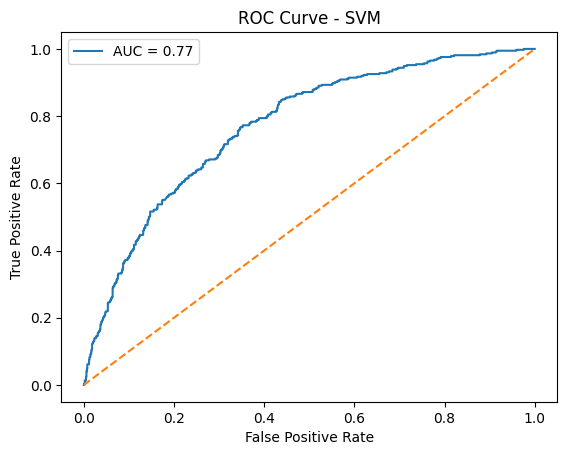

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

Conclusion & Discussion

In this study, a Support Vector Machine (SVM) model was implemented to predict customer churn in a telecom dataset. The model was trained on a preprocessed dataset, with additional feature scaling applied to ensure optimal performance. To address class imbalance, SMOTE was used to generate synthetic samples for the minority class.

The SVM model achieved an accuracy of approximately 75%, with a recall of 72% for churn prediction. This indicates that the model is effective in identifying customers who are likely to leave the service. The ROC curve further confirmed the model’s performance with an AUC score of 0.77, demonstrating good classification ability.

Overall, the SVM model performed well in this classification task and is suitable for churn prediction problems.

Although the model achieved reasonable performance, there are some limitations. The precision for churn prediction is relatively lower, indicating that some non-churn customers are incorrectly classified as churn. However, this trade-off is acceptable in churn prediction, as identifying potential churn customers is more critical than avoiding false positives.

Hyperparameter tuning using GridSearchCV was performed, but it resulted in lower recall compared to the baseline model. Therefore, the baseline model was preferred as it better captures churn cases.

Future improvements could include:

Feature selection to remove less important variables
Trying other machine learning algorithms such as Gradient Boosting or XGBoost
Using ensemble methods to improve performance
Further tuning of hyperparameters

These improvements could help enhance model accuracy and predictive power.

